# Semana 8: Reduccion de dimensionalidad
## Fundamentos de IA y Machine Learning (92-0025) | ULACIT
---

En este notebook aprenderemos **haciendo**. En lugar de ver diapositivas teoricas, vamos a ejecutar cada paso del workflow de reduccion de dimensionalidad y entender los conceptos a traves de la practica.

**Objetivos de aprendizaje:**
- Comprender por que tener muchas variables puede ser un problema (la maldicion de la dimensionalidad)
- Aplicar PCA (Analisis de Componentes Principales) paso a paso
- Interpretar los resultados de PCA en terminos de negocio
- Comparar PCA con otras tecnicas modernas (t-SNE, UMAP)
- Visualizar datos de alta dimension en 2D

> **Nota:** Este notebook esta disenado para estudiantes de negocios. No necesitas ser experto en programacion; lo importante es entender **que hace cada paso y por que**.

---
## Parte 0: Preparacion del entorno

Primero instalamos e importamos las librerias que necesitaremos.

In [20]:
# Instalamos UMAP (no viene preinstalado en Colab)
%pip install umap-learn --quiet

# Importamos librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import warnings
warnings.filterwarnings('ignore')

# Configuracion visual
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Colores ULACIT
PURPLE = '#2D1B4E'
CYAN = '#00D4FF'
COLORS = ['#2D1B4E', '#00D4FF', '#FF6B6B']

print('Entorno listo.')

Entorno listo.


---
## Parte 1: Conociendo nuestros datos

Vamos a trabajar con el **Wine Dataset** de scikit-learn. Este dataset contiene analisis quimicos de 178 vinos italianos provenientes de 3 cultivares (variedades de uva) diferentes. Para cada vino se midieron **13 variables quimicas**.

**Analogia de negocio:** Imaginen que son una empresa exportadora de vinos y necesitan clasificar sus productos. Tienen 13 mediciones por cada lote. Como visualizan y entienden patrones con tantas variables?

In [3]:
# Cargamos el dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target
target_names = wine.target_names

print(f'Dimensiones del dataset: {X.shape[0]} muestras x {X.shape[1]} variables')
print(f'\nClases (cultivares): {list(target_names)}')
print(f'\nVariables quimicas medidas:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')

Dimensiones del dataset: 178 muestras x 13 variables

Clases (cultivares): [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Variables quimicas medidas:
   1. alcohol
   2. malic_acid
   3. ash
   4. alcalinity_of_ash
   5. magnesium
   6. total_phenols
   7. flavanoids
   8. nonflavanoid_phenols
   9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline


In [4]:
# Exploracion rapida
X.describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


### Observacion clave

Miren las escalas de las variables. Por ejemplo, `proline` tiene valores en los cientos (746-1680), mientras que `nonflavanoid_phenols` va de 0.13 a 0.66. Esta diferencia de escalas sera muy importante cuando apliquemos PCA.

**Pregunta para reflexionar:** Si una variable tiene valores mucho mas grandes que otra, PCA la considerara mas importante? (Spoiler: si, y eso es un problema que resolveremos con estandarizacion.)

---
## Parte 2: La maldicion de la dimensionalidad

### Por que tantas variables son un problema?

Richard Bellman acuno el termino **"maldicion de la dimensionalidad"** en los anios 60. La idea central es: **a medida que agregamos mas variables, el espacio de datos crece exponencialmente**, haciendo que los puntos se dispersen y que las distancias entre ellos pierdan significado.

En la practica, esto significa que algoritmos basados en distancias (k-NN, k-Means) pierden efectividad porque todos los puntos quedan "igual de lejos" entre si. Regla practica: se necesitan al menos **5 muestras por dimension** para un modelado confiable.

**Dato 2025:** Un paper de ICML 2025 (Zhang et al.) demostro que incluso los Transformers (la arquitectura detras de ChatGPT, Claude, Gemini) sufren por la alta dimensionalidad: los pesos de atencion son dispersos pero consumen recursos computacionales iguales para todos los tokens.

Veamos esto con un experimento:

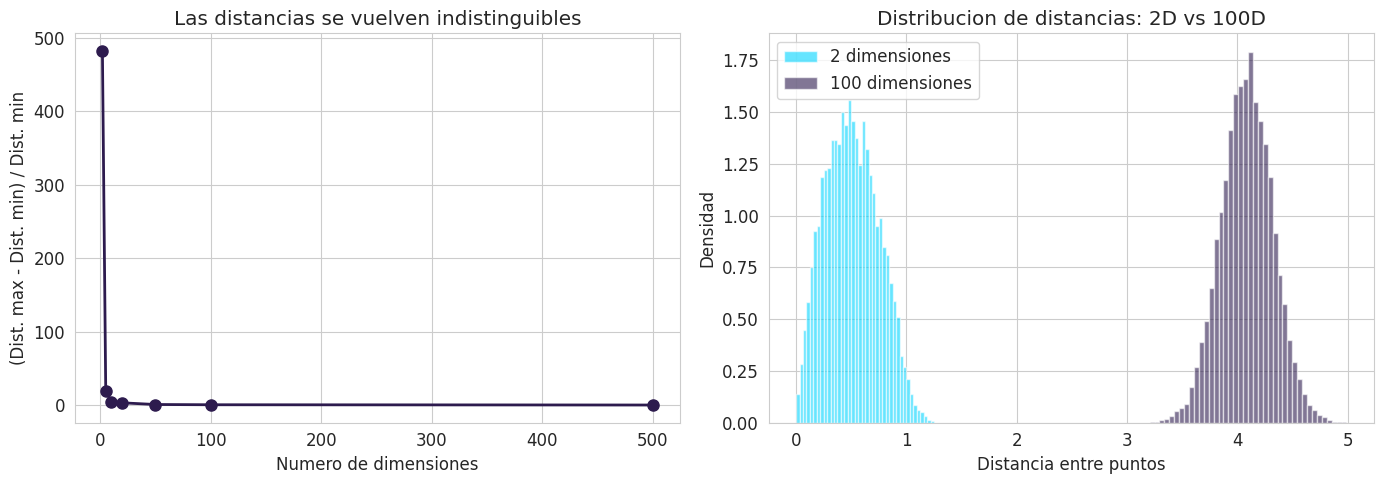

Interpretacion:
- Grafico izquierdo: la diferencia relativa entre distancias DISMINUYE con mas dimensiones.
  Esto significa que todos los puntos quedan "igual de lejos" entre si.
- Grafico derecho: en 100D, las distancias se concentran en un rango estrecho (campana angosta).
  Algoritmos como k-NN o k-Means dependen de distancias, asi que pierden efectividad.


In [5]:
# Experimento: como cambian las distancias al aumentar dimensiones
from sklearn.metrics import pairwise_distances

np.random.seed(42)
n_samples = 200
dimensions = [2, 5, 10, 20, 50, 100, 500]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ratios = []
for d in dimensions:
    data = np.random.uniform(0, 1, size=(n_samples, d))
    dists = pairwise_distances(data).flatten()
    dists = dists[dists > 0]  # quitar diagonal
    ratio = (dists.max() - dists.min()) / dists.min()
    ratios.append(ratio)

# Grafico 1: Ratio de distancias
axes[0].plot(dimensions, ratios, 'o-', color=PURPLE, linewidth=2, markersize=8)
axes[0].set_xlabel('Numero de dimensiones')
axes[0].set_ylabel('(Dist. max - Dist. min) / Dist. min')
axes[0].set_title('Las distancias se vuelven indistinguibles')

# Grafico 2: Histograma de distancias en 2D vs 100D
data_2d = np.random.uniform(0, 1, size=(n_samples, 2))
data_100d = np.random.uniform(0, 1, size=(n_samples, 100))

dists_2d = pairwise_distances(data_2d).flatten()
dists_100d = pairwise_distances(data_100d).flatten()

axes[1].hist(dists_2d[dists_2d > 0], bins=40, alpha=0.6, color=CYAN,
             label='2 dimensiones', density=True)
axes[1].hist(dists_100d[dists_100d > 0], bins=40, alpha=0.6, color=PURPLE,
             label='100 dimensiones', density=True)
axes[1].set_xlabel('Distancia entre puntos')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribucion de distancias: 2D vs 100D')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Interpretacion:')
print('- Grafico izquierdo: la diferencia relativa entre distancias DISMINUYE con mas dimensiones.')
print('  Esto significa que todos los puntos quedan "igual de lejos" entre si.')
print('- Grafico derecho: en 100D, las distancias se concentran en un rango estrecho (campana angosta).')
print('  Algoritmos como k-NN o k-Means dependen de distancias, asi que pierden efectividad.')

### Impacto practico en nuestro dataset de vinos

Con 13 variables, intentemos visualizar los datos. El problema: nosotros solo podemos ver en 2D o 3D.

Con 13 variables, tendriamos que mirar 78 graficos de pares.
Eso es impractico. Veamos solo 6 pares aleatorios para ilustrar el problema:



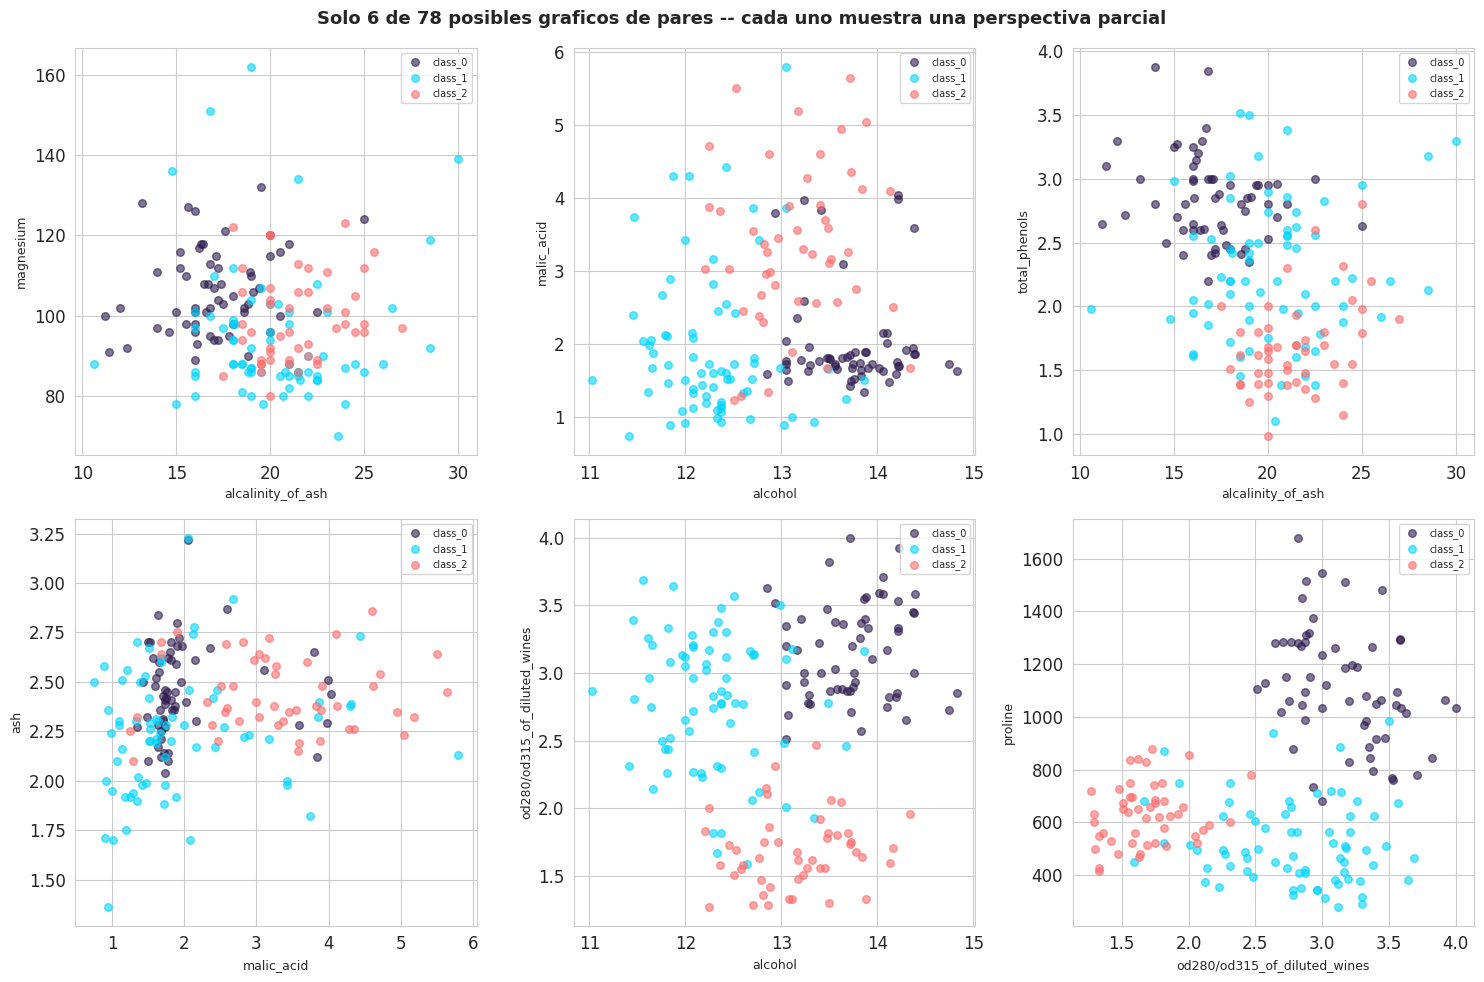

Ninguno de estos graficos muestra la imagen COMPLETA.
Necesitamos una forma de ver TODA la informacion en un solo grafico de 2D.
Esa es exactamente la promesa de la reduccion de dimensionalidad.


In [6]:
# Intentemos graficar todas las combinaciones de pares de variables
from itertools import combinations

n_vars = len(X.columns)
n_pairs = n_vars * (n_vars - 1) // 2
print(f'Con {n_vars} variables, tendriamos que mirar {n_pairs} graficos de pares.')
print('Eso es impractico. Veamos solo 6 pares aleatorios para ilustrar el problema:\n')

np.random.seed(42)
pairs = list(combinations(range(n_vars), 2))
selected_pairs = [pairs[i] for i in np.random.choice(len(pairs), 6, replace=False)]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (i, j) in zip(axes.flatten(), selected_pairs):
    for cls in range(3):
        mask = y == cls
        ax.scatter(X.iloc[mask, i], X.iloc[mask, j], c=COLORS[cls],
                   alpha=0.6, label=target_names[cls], s=30)
    ax.set_xlabel(X.columns[i], fontsize=9)
    ax.set_ylabel(X.columns[j], fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Solo 6 de 78 posibles graficos de pares -- cada uno muestra una perspectiva parcial',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Ninguno de estos graficos muestra la imagen COMPLETA.')
print('Necesitamos una forma de ver TODA la informacion en un solo grafico de 2D.')
print('Esa es exactamente la promesa de la reduccion de dimensionalidad.')

### Otro problema: la correlacion entre variables

Muchas de nuestras 13 variables probablemente miden cosas similares. Esa **redundancia** significa que no todas aportan informacion unica.

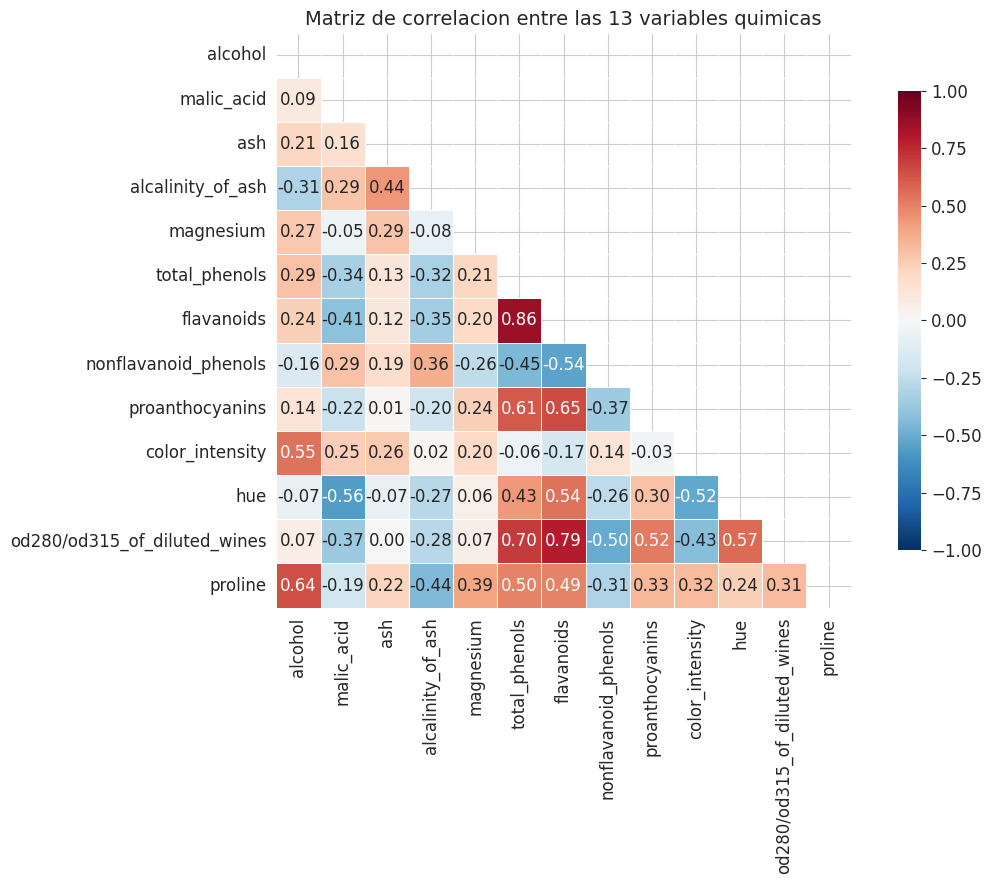


Pares de variables con correlacion fuerte (|r| > 0.6):
  total_phenols                  <-> flavanoids                      r = +0.865
  flavanoids                     <-> od280/od315_of_diluted_wines    r = +0.787
  total_phenols                  <-> od280/od315_of_diluted_wines    r = +0.700
  flavanoids                     <-> proanthocyanins                 r = +0.653
  alcohol                        <-> proline                         r = +0.644
  total_phenols                  <-> proanthocyanins                 r = +0.612


In [7]:
# Mapa de calor de correlaciones
fig, ax = plt.subplots(figsize=(12, 9))
corr = X.corr()
mask_corr = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlacion entre las 13 variables quimicas', fontsize=14)
plt.tight_layout()
plt.show()

# Identificar las correlaciones mas fuertes
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.6:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print('\nPares de variables con correlacion fuerte (|r| > 0.6):')
for v1, v2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f'  {v1:30s} <-> {v2:30s}  r = {r:+.3f}')

**Conclusion de esta seccion:**
- Con muchas variables, las distancias pierden significado (algoritmos como k-NN y k-Means sufren).
- No podemos visualizar mas de 2-3 variables a la vez.
- Muchas variables estan correlacionadas, es decir, llevan informacion redundante.

**La solucion:** Reducir dimensiones, conservando la mayor cantidad de informacion posible. Aqui es donde entra **PCA**.

---
## Parte 3: PCA (Analisis de Componentes Principales) - paso a paso

### Que hace PCA?

PCA transforma nuestras variables originales (correlacionadas) en un nuevo conjunto de variables **no correlacionadas** llamadas **componentes principales**. Estas estan ordenadas: la primera captura la mayor varianza posible, la segunda la mayor varianza restante (ortogonal a la primera), y asi sucesivamente.

**Analogia:** Imaginen que tienen una nube de puntos 3D que en realidad se extiende principalmente a lo largo de un plano. PCA encuentra ese plano y proyecta los puntos sobre el, reduciendo de 3D a 2D con perdida minima de informacion.

### Paso 1: Estandarizar los datos

PCA es **sensible a la escala**. Si no estandarizamos, las variables con valores grandes (como `proline`) dominaran los componentes, no porque sean mas informativas sino simplemente porque tienen numeros mas grandes.

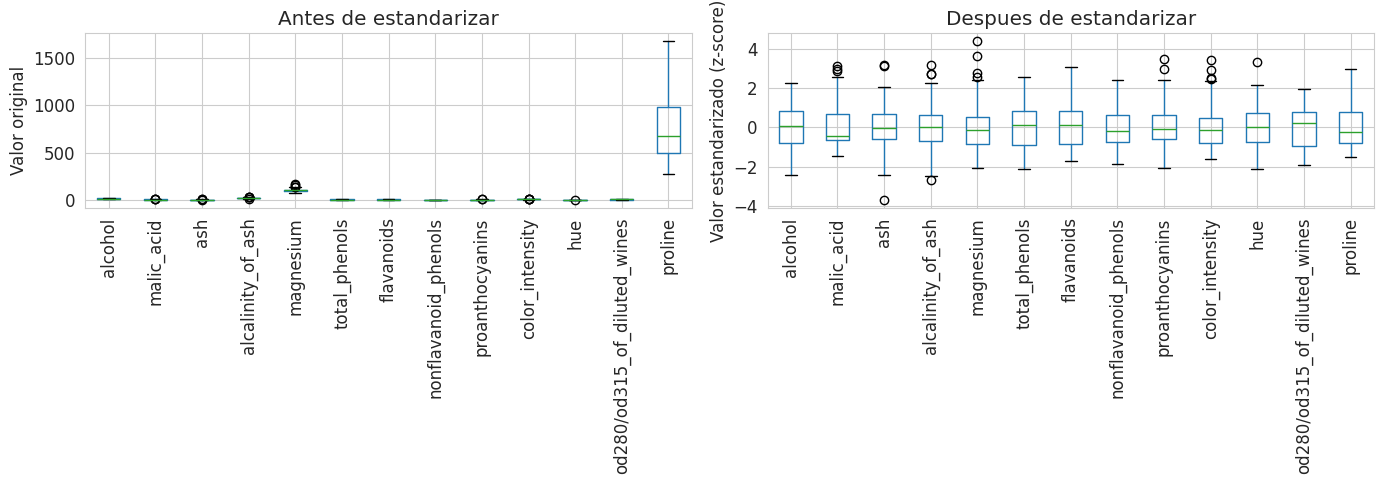

Ahora todas las variables tienen media 0 y desviacion estandar 1.
PCA las tratara en igualdad de condiciones.


In [8]:
# Estandarizacion: media = 0, desviacion estandar = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Comparar antes y despues
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

X.boxplot(ax=axes[0], rot=90)
axes[0].set_title('Antes de estandarizar')
axes[0].set_ylabel('Valor original')

X_scaled.boxplot(ax=axes[1], rot=90)
axes[1].set_title('Despues de estandarizar')
axes[1].set_ylabel('Valor estandarizado (z-score)')

plt.tight_layout()
plt.show()

print('Ahora todas las variables tienen media 0 y desviacion estandar 1.')
print('PCA las tratara en igualdad de condiciones.')

### Paso 2: Aplicar PCA y analizar la varianza explicada

Ahora aplicamos PCA con todas las componentes para entender cuanta informacion captura cada una. La pregunta clave es: **cuantos componentes necesitamos retener?**

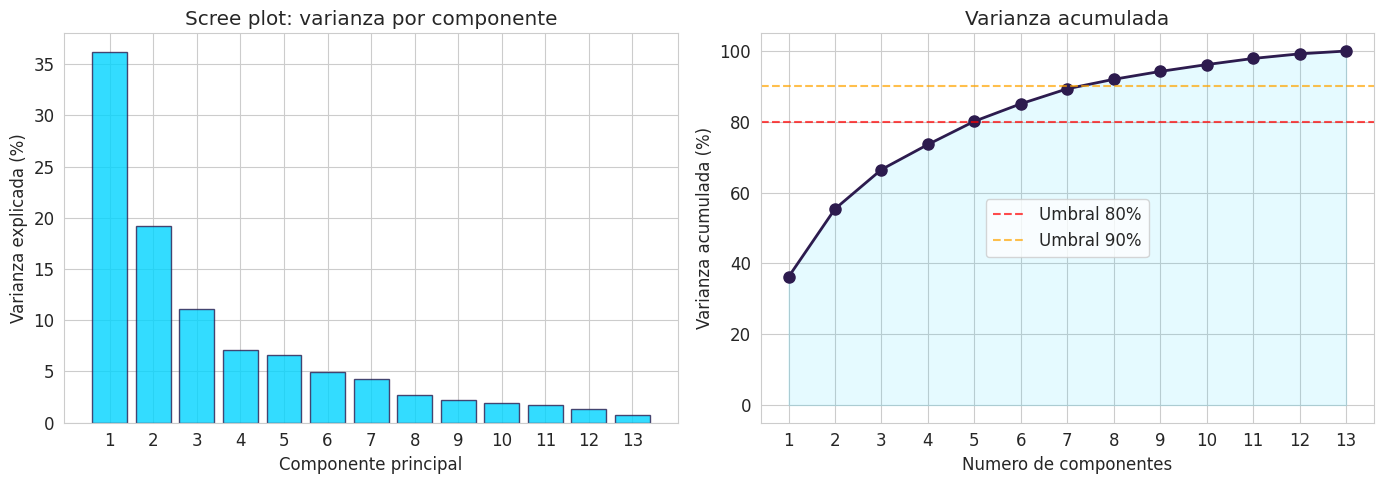


Resumen de varianza explicada:
  Componente    Var. Individual     Var. Acumulada
--------------------------------------------------
         PC1             36.20%             36.20%
         PC2             19.21%             55.41%
         PC3             11.12%             66.53%
         PC4              7.07%             73.60%
         PC5              6.56%             80.16%
         PC6              4.94%             85.10%
         PC7              4.24%             89.34%
         PC8              2.68%             92.02%
         PC9              2.22%             94.24%
        PC10              1.93%             96.17%
        PC11              1.74%             97.91%
        PC12              1.30%             99.20%
        PC13              0.80%            100.00%

Para capturar 80% de la varianza: 5 componentes (de 13 originales)

Para capturar 85% de la varianza: 6 componentes (de 13 originales)

Para capturar 90% de la varianza: 8 componentes (de 13 originales)

In [9]:
# Aplicar PCA con todos los componentes
pca_full = PCA()
pca_full.fit(X_scaled)

# Varianza explicada
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

# Grafico de varianza explicada (Scree Plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(var_exp)+1), var_exp * 100,
            color=CYAN, edgecolor=PURPLE, alpha=0.8)
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Scree plot: varianza por componente')
axes[0].set_xticks(range(1, len(var_exp)+1))

# Varianza acumulada
axes[1].plot(range(1, len(var_cum)+1), var_cum * 100, 'o-',
             color=PURPLE, linewidth=2, markersize=8)
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='Umbral 80%')
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='Umbral 90%')
axes[1].fill_between(range(1, len(var_cum)+1), var_cum * 100, alpha=0.1, color=CYAN)
axes[1].set_xlabel('Numero de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada')
axes[1].set_xticks(range(1, len(var_cum)+1))
axes[1].legend()

plt.tight_layout()
plt.show()

# Tabla de resultados
print('\nResumen de varianza explicada:')
print(f'{"Componente":>12} {"Var. Individual":>18} {"Var. Acumulada":>18}')
print('-' * 50)
for i in range(len(var_exp)):
    print(f'{"PC" + str(i+1):>12} {var_exp[i]*100:>17.2f}% {var_cum[i]*100:>17.2f}%')

# Cuantos componentes necesitamos?
for threshold in [0.80, 0.85, 0.90, 0.95]:
    n = np.argmax(var_cum >= threshold) + 1
    print(f'\nPara capturar {threshold*100:.0f}% de la varianza: {n} componentes (de 13 originales)')

### Reflexion importante

Observen como con solo **3-5 componentes** capturamos la gran mayoria de la informacion. Esto significa que las 13 variables originales contenian mucha redundancia (correlaciones), y PCA la elimino.

**En terminos de negocio:** En lugar de analizar 13 metricas quimicas, podriamos trabajar con ~4 "super-variables" que resumen el 80%+ de toda la informacion. Menos variables = modelos mas simples, rapidos y menos propensos al sobreajuste.

### Paso 3: Interpretar los componentes principales

Cada componente principal es una **combinacion lineal** de las variables originales. Los "loadings" (cargas) nos dicen cuanto contribuye cada variable a cada componente. Esto es lo que hace a PCA **interpretable** a diferencia de otras tecnicas.

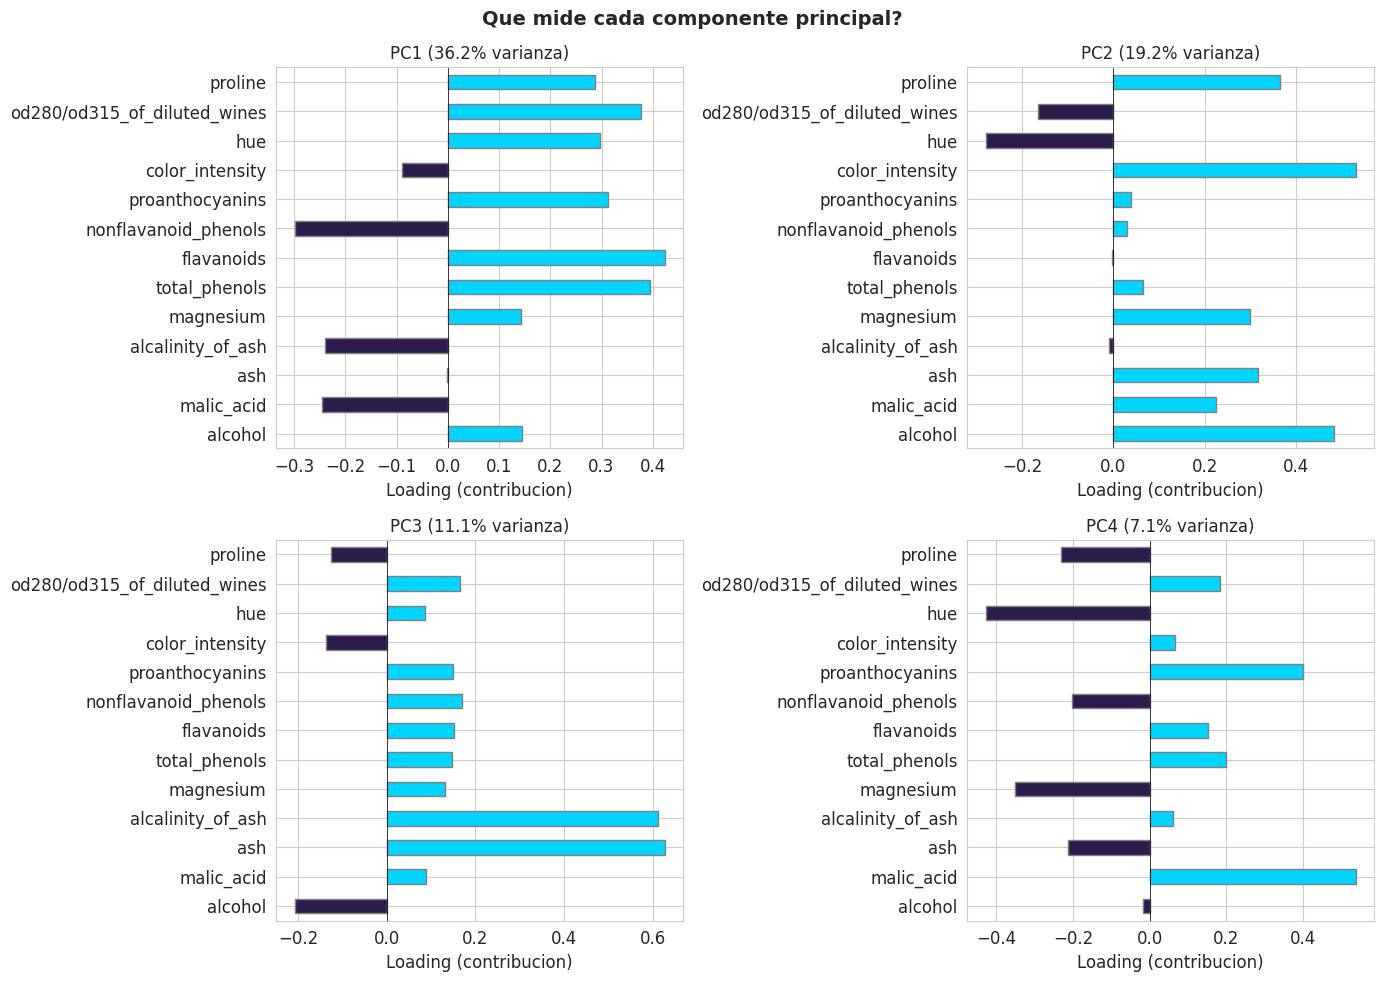

Tabla de loadings:
                                PC1    PC2    PC3    PC4
alcohol                       0.144  0.484 -0.207 -0.018
malic_acid                   -0.245  0.225  0.089  0.537
ash                          -0.002  0.316  0.626 -0.214
alcalinity_of_ash            -0.239 -0.011  0.612  0.061
magnesium                     0.142  0.300  0.131 -0.352
total_phenols                 0.395  0.065  0.146  0.198
flavanoids                    0.423 -0.003  0.151  0.152
nonflavanoid_phenols         -0.299  0.029  0.170 -0.203
proanthocyanins               0.313  0.039  0.149  0.399
color_intensity              -0.089  0.530 -0.137  0.066
hue                           0.297 -0.279  0.085 -0.428
od280/od315_of_diluted_wines  0.376 -0.164  0.166  0.184
proline                       0.287  0.365 -0.127 -0.232


In [10]:
# Loadings de las primeras 4 componentes
n_components_show = 4
loadings = pd.DataFrame(
    pca_full.components_[:n_components_show].T,
    columns=[f'PC{i+1}' for i in range(n_components_show)],
    index=X.columns
)

# Visualizar loadings
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, ax in enumerate(axes.flatten()):
    if i < n_components_show:
        colors = [CYAN if v >= 0 else PURPLE for v in loadings[f'PC{i+1}']]
        loadings[f'PC{i+1}'].plot(kind='barh', ax=ax, color=colors, edgecolor='gray')
        ax.set_title(f'PC{i+1} ({var_exp[i]*100:.1f}% varianza)', fontsize=12)
        ax.axvline(x=0, color='black', linewidth=0.5)
        ax.set_xlabel('Loading (contribucion)')

plt.suptitle('Que mide cada componente principal?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Tabla de loadings:')
print(loadings.round(3).to_string())

### Interpretacion en terminos de negocio

Miremos las variables con mayor peso (loading) en cada componente para darles un "nombre" intuitivo:

- **PC1** (mayor varianza): Captura el "perfil general de calidad" del vino, combinando flavanoides, fenoles, prolina y OD280.
- **PC2**: Refleja la "intensidad de color y composicion mineral" (color_intensity, alcalinity_of_ash, ash).
- **PC3 y PC4**: Capturan variaciones mas sutiles en la composicion.

**Punto clave para negocios:** Los componentes principales no son variables individuales; son **"dimensiones resumen"** que combinan multiples metricas. Un gerente de calidad no diria "el flavonoide es alto" sino "el PC1 (perfil de calidad) es alto", resumiendo varias mediciones en una sola dimension.

**Dato 2025:** Un estudio publicado en JMIR Aging (2025) demostro que PCA aplicado antes de redes neuronales para diagnosticar Alzheimer a partir de datos de escritura manual logro 91% de precision y 94% de AUC. Reducir dimensiones no solo simplifica: puede mejorar los resultados al eliminar ruido.

### Paso 4: Visualizar en 2D con PCA

Ahora proyectamos todos los vinos al espacio de 2 componentes principales. Esto es pasar de 13 dimensiones (imposible de visualizar) a 2 dimensiones (un grafico simple).

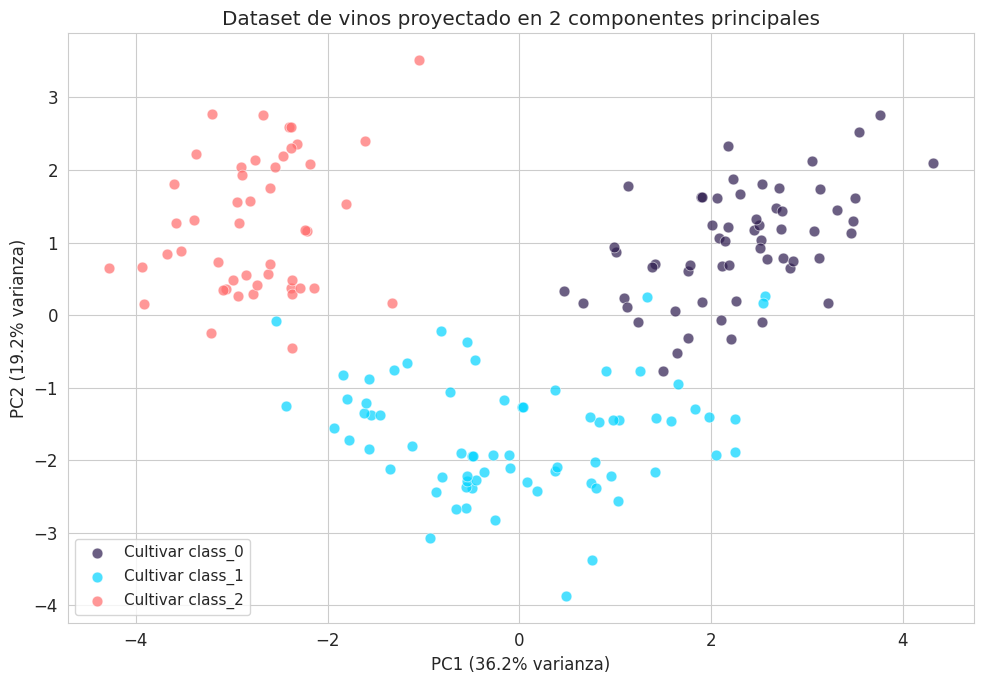

Con solo 2 componentes capturamos 55.4% de la varianza total.
Pasamos de 13 dimensiones a 2, y los 3 cultivares se separan claramente.

Esto es el poder de PCA: revelar estructura oculta en datos complejos.


In [11]:
# PCA con 2 componentes para visualizacion
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
for cls in range(3):
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLORS[cls], label=f'Cultivar {target_names[cls]}',
               s=60, alpha=0.7, edgecolors='white', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Dataset de vinos proyectado en 2 componentes principales')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

total_var = sum(pca_2d.explained_variance_ratio_) * 100
print(f'Con solo 2 componentes capturamos {total_var:.1f}% de la varianza total.')
print('Pasamos de 13 dimensiones a 2, y los 3 cultivares se separan claramente.')
print('\nEsto es el poder de PCA: revelar estructura oculta en datos complejos.')

### Paso 5: Biplot - la herramienta de visualizacion mas poderosa de PCA

El **biplot** muestra simultaneamente:
- Los puntos (muestras de vino) proyectados en 2D
- Las flechas (variables originales) indicando su contribucion a cada componente

Es como un mapa que muestra tanto la ubicacion de los vinos como las "fuerzas" que determinan esa ubicacion.

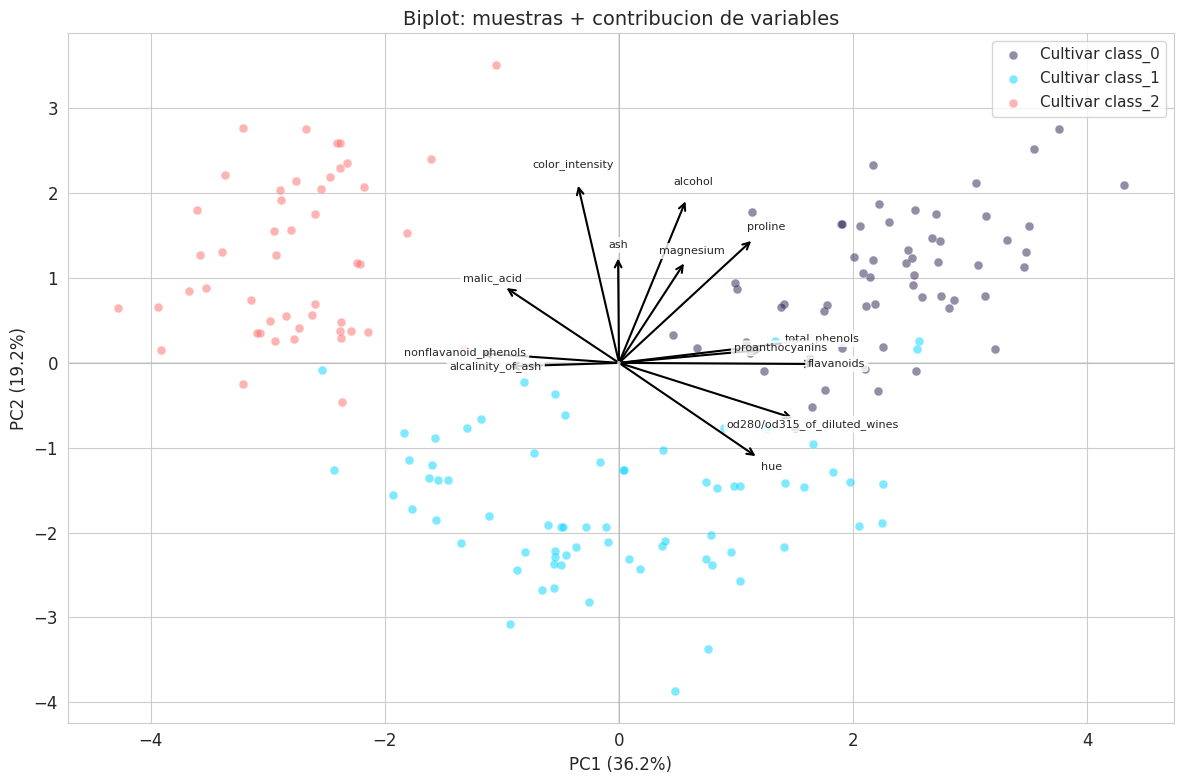

Como leer el biplot:
- Las flechas largas representan variables que contribuyen mucho a la separacion.
- Flechas que apuntan en la misma direccion: variables positivamente correlacionadas.
- Flechas opuestas: variables negativamente correlacionadas.
- Flechas perpendiculares: variables no correlacionadas entre si.


In [15]:
# Biplot
fig, ax = plt.subplots(figsize=(12, 8))

# Puntos
for cls in range(3):
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLORS[cls], label=f'Cultivar {target_names[cls]}',
               s=40, alpha=0.5, edgecolors='white', linewidth=0.3)

# Flechas (loadings escalados)
loadings_2d = pca_2d.components_.T
scale = 4  # escalar para visibilidad
for i, feature in enumerate(X.columns):
    ax.annotate('',
                xy=(loadings_2d[i, 0] * scale, loadings_2d[i, 1] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(loadings_2d[i, 0] * scale * 1.1,
            loadings_2d[i, 1] * scale * 1.1,
            feature, fontsize=8, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Biplot: muestras + contribucion de variables', fontsize=14)
ax.legend(fontsize=11)
ax.axhline(y=0, color='gray', linewidth=0.3)
ax.axvline(x=0, color='gray', linewidth=0.3)
plt.tight_layout()
plt.show()

print('Como leer el biplot:')
print('- Las flechas largas representan variables que contribuyen mucho a la separacion.')
print('- Flechas que apuntan en la misma direccion: variables positivamente correlacionadas.')
print('- Flechas opuestas: variables negativamente correlacionadas.')
print('- Flechas perpendiculares: variables no correlacionadas entre si.')

---
## Parte 4: Comparacion con otras tecnicas modernas

PCA es el metodo clasico (lineal, rapido, interpretable). Pero existen metodos **no lineales** que pueden capturar relaciones mas complejas. Veamos como se comparan **t-SNE** y **UMAP** con PCA en nuestros datos.

### Cuando usar cada uno?

| Tecnica | Tipo | Velocidad | Interpretabilidad | Mejor para |
|---------|------|-----------|-------------------|-----------|
| PCA | Lineal | Muy rapida | Alta (loadings) | Preprocesamiento, analisis, compresion |
| t-SNE | No lineal | Lenta | Baja | Visualizacion de clusters locales |
| UMAP | No lineal | Rapida | Media | Visualizacion + estructura global y local |

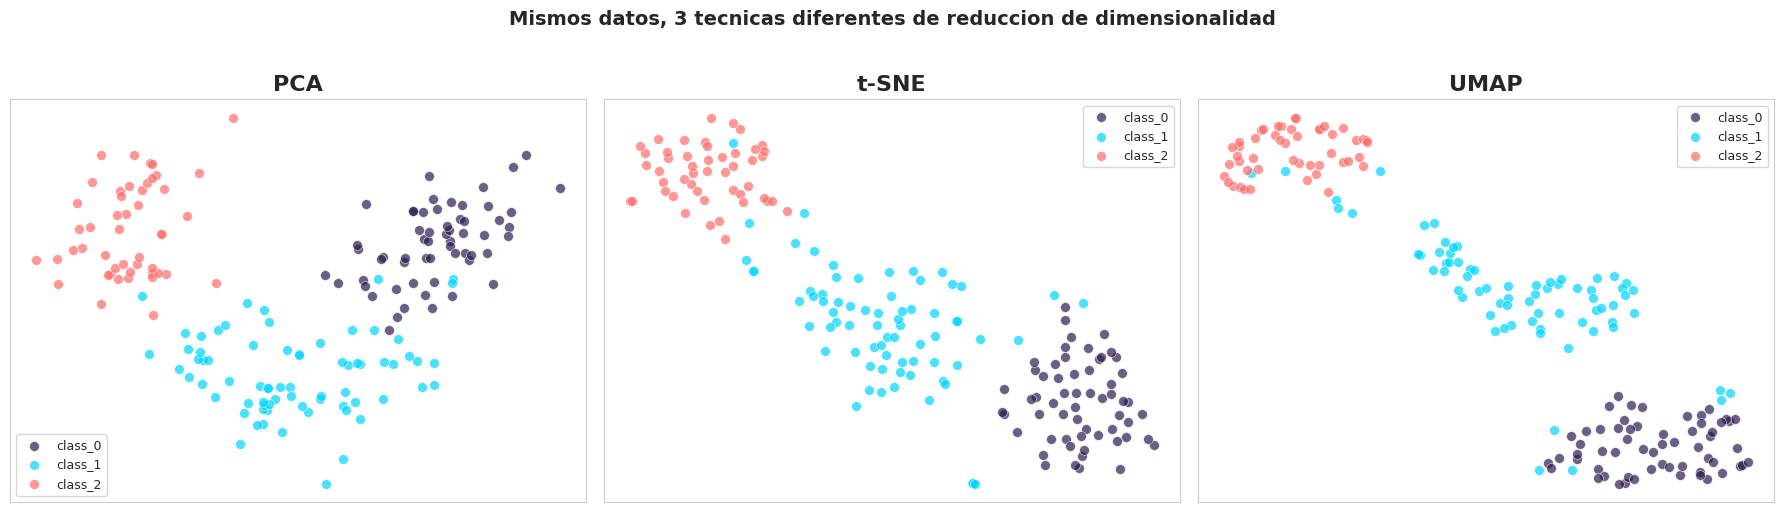

Observaciones:
- PCA: Separacion lineal. Los ejes tienen significado (varianza explicada). Rapido y reproducible.
- t-SNE: Clusters mas apretados y separados. Bueno para explorar agrupaciones locales.
         Pero: los ejes NO tienen significado, y las distancias entre clusters no son confiables.
- UMAP: Balance entre estructura local y global. Mas rapido que t-SNE.

Para analisis de negocio, PCA suele ser la primera opcion por su interpretabilidad.
Para exploracion visual, t-SNE o UMAP complementan bien.


In [16]:
# Aplicar t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, init='pca')
X_tsne = tsne.fit_transform(X_scaled)

# Aplicar UMAP
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_scaled)

# Comparacion visual lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
methods = [('PCA', X_pca), ('t-SNE', X_tsne), ('UMAP', X_umap)]

for ax, (name, data) in zip(axes, methods):
    for cls in range(3):
        mask = y == cls
        ax.scatter(data[mask, 0], data[mask, 1],
                   c=COLORS[cls], label=f'{target_names[cls]}',
                   s=50, alpha=0.7, edgecolors='white', linewidth=0.5)
    ax.set_title(name, fontsize=16, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Mismos datos, 3 tecnicas diferentes de reduccion de dimensionalidad',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Observaciones:')
print('- PCA: Separacion lineal. Los ejes tienen significado (varianza explicada). Rapido y reproducible.')
print('- t-SNE: Clusters mas apretados y separados. Bueno para explorar agrupaciones locales.')
print('         Pero: los ejes NO tienen significado, y las distancias entre clusters no son confiables.')
print('- UMAP: Balance entre estructura local y global. Mas rapido que t-SNE.')
print('\nPara analisis de negocio, PCA suele ser la primera opcion por su interpretabilidad.')
print('Para exploracion visual, t-SNE o UMAP complementan bien.')

### Cuidado con t-SNE: los parametros cambian todo

Un dato importante: t-SNE produce resultados diferentes segun el parametro **perplexity** (perplejidad). Los tamanos de clusters y las distancias entre clusters en t-SNE **no son confiables**. Esto fue documentado en el clasico articulo de Distill.pub.

Veamos como cambia el resultado con diferentes valores:

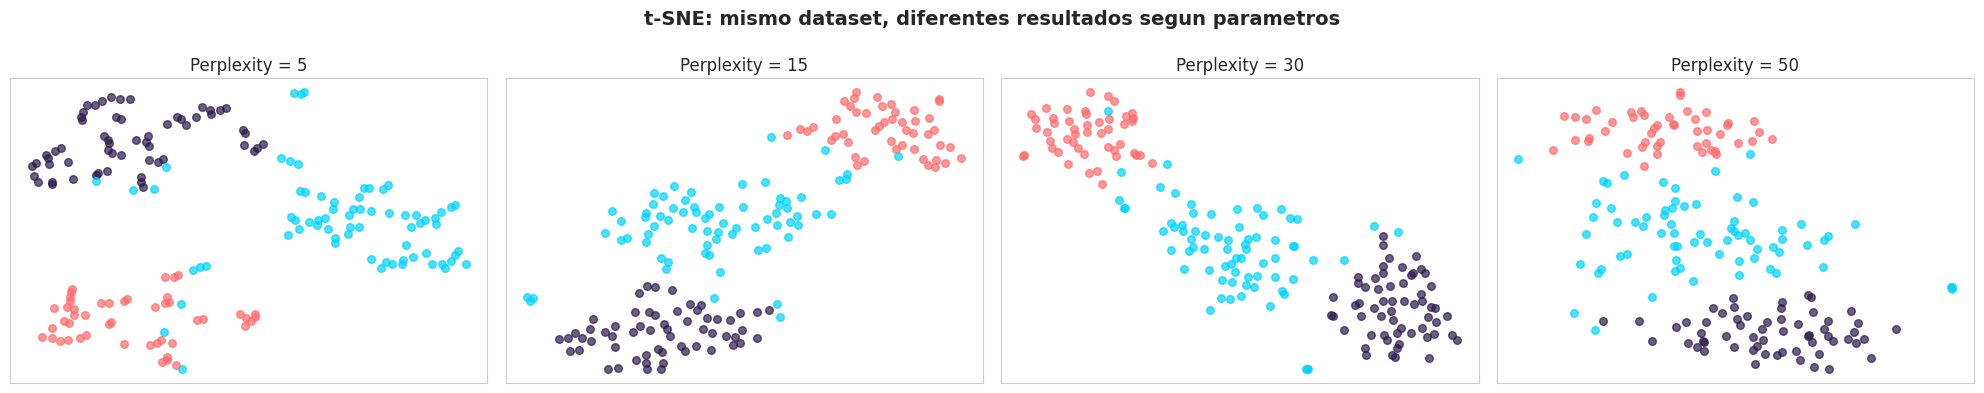

Leccion: siempre hay que probar multiples configuraciones de t-SNE y no confiar
en una sola corrida. PCA, en cambio, siempre da el mismo resultado (es deterministico).


In [17]:
# t-SNE con diferentes perplejidades
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, perp in zip(axes, perplexities):
    tsne_var = TSNE(n_components=2, random_state=42, perplexity=perp, n_iter=1000, init='pca')
    X_tsne_var = tsne_var.fit_transform(X_scaled)
    for cls in range(3):
        mask = y == cls
        ax.scatter(X_tsne_var[mask, 0], X_tsne_var[mask, 1],
                   c=COLORS[cls], s=30, alpha=0.7)
    ax.set_title(f'Perplexity = {perp}', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('t-SNE: mismo dataset, diferentes resultados segun parametros',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Leccion: siempre hay que probar multiples configuraciones de t-SNE y no confiar')
print('en una sola corrida. PCA, en cambio, siempre da el mismo resultado (es deterministico).')

---
## Parte 5: Aplicacion practica - PCA como preprocesamiento para clustering

En la semana 7 vimos clustering con K-Means. Veamos como PCA puede **mejorar** el clustering al reducir ruido y dimensiones.

**Contexto de negocio:** Supongamos que NO sabemos los cultivares y queremos descubrir grupos naturales en los datos.

Comparacion: K-Means con y sin PCA previo
Metrica                        Sin PCA (13D) Con PCA (4D)
-------------------------------------------------------
Silhouette Score                     0.2849       0.4066
Adjusted Rand Index                  0.8975       0.8471
Dimensiones usadas                       13            4
Varianza retenida                      100%        73.6%


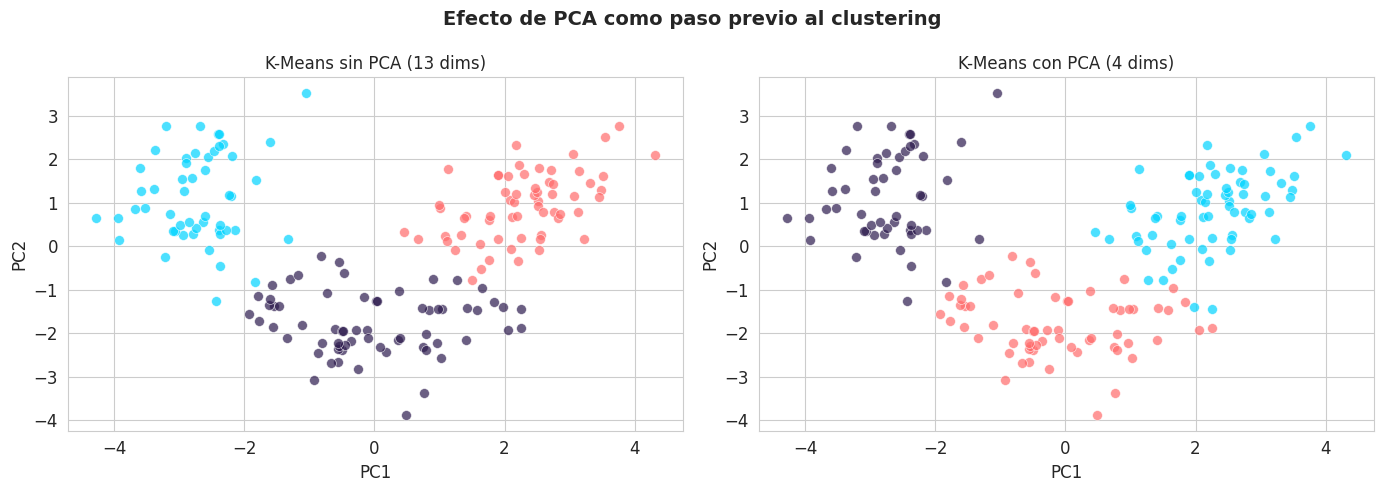


Reducir dimensiones con PCA antes de clustering puede:
  - Eliminar ruido y variables redundantes
  - Acelerar el algoritmo de clustering
  - Frecuentemente mejorar la calidad de los clusters


In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Clustering sin PCA (13 dimensiones)
kmeans_full = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_full = kmeans_full.fit_predict(X_scaled)

# Clustering con PCA (4 componentes, ~80% varianza)
pca_4 = PCA(n_components=4)
X_pca4 = pca_4.fit_transform(X_scaled)
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca4)

# Comparar resultados
sil_full = silhouette_score(X_scaled, labels_full)
sil_pca = silhouette_score(X_pca4, labels_pca)
ari_full = adjusted_rand_score(y, labels_full)
ari_pca = adjusted_rand_score(y, labels_pca)

print('Comparacion: K-Means con y sin PCA previo')
print('=' * 55)
print(f'{"Metrica":<30} {"Sin PCA (13D)":>12} {"Con PCA (4D)":>12}')
print('-' * 55)
print(f'{"Silhouette Score":<30} {sil_full:>12.4f} {sil_pca:>12.4f}')
print(f'{"Adjusted Rand Index":<30} {ari_full:>12.4f} {ari_pca:>12.4f}')
print(f'{"Dimensiones usadas":<30} {13:>12} {4:>12}')
print(f'{"Varianza retenida":<30} {"100%":>12} {pca_4.explained_variance_ratio_.sum()*100:>11.1f}%')

# Visualizar ambos resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Proyectar todo a 2D para visualizacion
X_vis = PCA(n_components=2).fit_transform(X_scaled)

for ax, labels, title in zip(axes,
                              [labels_full, labels_pca],
                              ['K-Means sin PCA (13 dims)', 'K-Means con PCA (4 dims)']):
    for cls in range(3):
        mask = labels == cls
        ax.scatter(X_vis[mask, 0], X_vis[mask, 1],
                   c=COLORS[cls], s=50, alpha=0.7, edgecolors='white', linewidth=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('Efecto de PCA como paso previo al clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nReducir dimensiones con PCA antes de clustering puede:')
print('  - Eliminar ruido y variables redundantes')
print('  - Acelerar el algoritmo de clustering')
print('  - Frecuentemente mejorar la calidad de los clusters')

---
## Parte 6: Resumen y conexion con el caso de clase

### Workflow completo de reduccion de dimensionalidad

1. **Entender el problema:** Por que tener muchas variables es problematico? (maldicion de la dimensionalidad, correlaciones, imposibilidad de visualizar)
2. **Explorar los datos:** Analizar escalas, correlaciones, distribuciones
3. **Estandarizar:** Llevar todas las variables a la misma escala (obligatorio para PCA)
4. **Aplicar PCA:** Obtener componentes principales ordenados por varianza explicada
5. **Decidir cuantos componentes retener:** Scree plot, varianza acumulada (regla de 80-90%), criterio de Kaiser
6. **Interpretar:** Analizar loadings para dar significado de negocio a los componentes
7. **Visualizar:** Graficos 2D, biplots
8. **Usar:** Como preprocesamiento para clustering, clasificacion, u otros modelos

### Panorama de tecnicas (2025-2026)

| Tecnica | Tipo | Fortaleza principal |
|---------|------|--------------------|
| PCA | Lineal | Interpretabilidad, velocidad, preprocesamiento |
| t-SNE | No lineal | Visualizacion de clusters locales |
| UMAP | No lineal | Velocidad + estructura global y local |
| PaCMAP | No lineal | Mejor balance local-global (emergente 2024-2025) |
| Autoencoders | Deep learning | Compresion compleja, datos no tabulares |
| Matryoshka Embeddings | Entrenamiento integrado | Compresion de embeddings de LLMs (OpenAI, Alibaba) |

### Datos de Costa Rica

- Costa Rica ocupa el **5to lugar** en el Indice Latinoamericano de IA (ILIA 2025)
- **76%** de empresas tech costarricenses usan IA generativa (Procomer, 2026)
- La industria cafetalera costarricense ($442M en exportaciones, 2024) ya usa PCA para autenticacion de calidad mediante espectroscopia NIR, con 91-100% de precision
- ECOM Costa Rica trabaja con 100 productores de cafe usando IA sobre datos de alta dimension del microbioma del suelo

### Ahora: a trabajar en el Caso 7

En el caso que sigue, aplicaran estos conceptos a un escenario real: una cooperativa de cafe de Tarrazu que necesita usar PCA para autenticar la calidad de sus lotes de cafe especial.

---
*Notebook desarrollado para el curso 92-0025 Fundamentos de IA y Machine Learning | ULACIT | 3CO-2025*